##1. Bibliotecas

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np


## 2. Definimos o símbolo (Ticker).

Exemplo: 'AAPL' (Apple) ou 'DIS' (Disney)

In [ ]:
symbol = 'PETR4.SA'

##3. Período de análise

(Recomendado: pelo menos 5 anos para séries temporais)

In [ ]:
start_date = '2018-01-01'
end_date = '2024-07-20'

##4. Download dos dados

O yfinance retorna um DataFrame do Pandas com Open, High, Low, Close, etc

In [ ]:
df = yf.download(symbol, start=start_date, end=end_date)

/tmp/ipykernel_2168/959484986.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


##5. Exibindo as primeiras linhas para conferência

Abaixo, preparamos o ambiente. Note que definimos uma data de início e fim. É crucial ter um período longo o suficiente (mínimo 5 anos) para que a LSTM aprenda padrões de crise e alta.

In [ ]:
print(df.head())

Price          Close      High       Low      Open    Volume
Ticker      PETR4.SA  PETR4.SA  PETR4.SA  PETR4.SA  PETR4.SA
Date                                                        
2018-01-02  4.351433  4.351433  4.256780  4.256780  33461800
2018-01-03  4.390872  4.396130  4.304106  4.335657  55940900
2018-01-04  4.398760  4.459233  4.369839  4.411907  37064900
2018-01-05  4.425052  4.432940  4.356691  4.390872  26958200
2018-01-08  4.477638  4.477638  4.393501  4.401389  28400000


##6.Normalização e Janelamento

Aqui vamos isolar a coluna de fechamento (Close), normalizar e criar as janelas.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:

#Preço de fechamento
data = df[['Close']].values

#Normalização: escalonando entre 0 e 1
scaler = MinMaxScaler(feature_range= (0, 1))
scaled_data = scaler.fit_transform(data)

#Janelas temporais (LOOKBACK)

prediction_days = 60  
x_train = []
y_train = []

for x in range(prediction_days, len(scaled_data)):
  x_train.append(scaled_data[x-prediction_days:x, 0])
  y_train.append(scaled_data[x, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

#Reshape para o formato que a LSTM exige amostras, timesteps, features
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print(f"Dados preparados! Formato do X: {x_train.shape}")

Dados preparados! Formato do X: (1566, 60, 1)


##7. Construção da Arquitetura LSTM

Vamos construir um modelo sequencial usando o TensorFlow/Keras. Adicionaremos camadas de Dropout, que servem para evitar o overfitting

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# Inicializando o model sequencial
model = Sequential()


#Primeira camada LSTM
model.add(LSTM(units=50, return_sequences= True, input_shape= (x_train.shape[1], 1)))
model.add(Dropout(0.2)) #evita o vicio da rede em dados

#Segunda camada LSTM
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

#Camada de saida (Dense)
model.add(Dense(units=1))

#Compilação do Modelo
#usei o otimizador 'adam' e a perda MSE para regressão
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary() #exibe a arquitetura do modelo

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

##8. Treinamento e Ajuste de Hiperparâmetros

Para séries temporais, é fundamental que a validação seja composta pelos dados mais recentes, sem embaralhar (shuffle=False), para simular o mundo real onde o futuro vem depois do passado.

Epoch 1/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - loss: 0.0017 - val_loss: 0.0403
Epoch 2/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - loss: 0.0019 - val_loss: 0.0406
Epoch 3/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.0013 - val_loss: 0.0281
Epoch 4/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 9.6863e-04 - val_loss: 0.0275
Epoch 5/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 9.5426e-04 - val_loss: 0.0265
Epoch 6/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 8.0413e-04 - val_loss: 0.0194
Epoch 7/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 6.4971e-04 - val_loss: 0.0225
Epoch 8/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 6.3445e-04 - val_loss: 0.0235
Epoch 9/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 8.2152e-04 - val_loss: 0.0190
Epoch 10/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step - loss: 6.8934e-04 - val_loss: 0.0252
Epoch 11/25
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 6.1362e-04 - val_loss: 0.0290
Epoch 12/25
40/40 ━━━━━━━━━━━━━

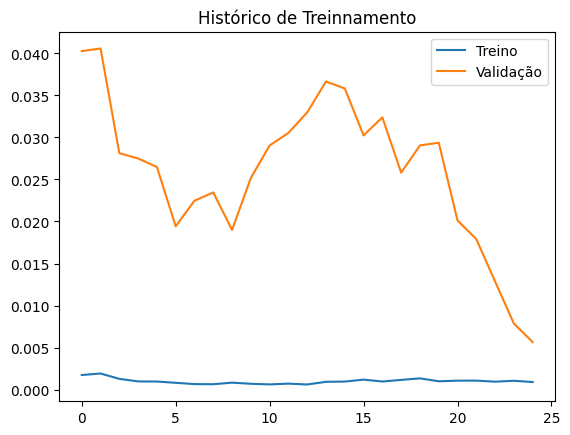

In [ ]:
#Definindo o tamanho do treino (80%)
train_size = int(len(x_train)* 0.8)

x_val, y_val = x_train[train_size:], y_train[train_size:]
x_train_final, y_train_final = x_train[:train_size], y_train[:train_size]

#Executando o treinamento
#epochs=25 e bom para evitar overfitting e não demorar no colab
#batch_size= 32 é o padrão da industria

history = model.fit(
    x_train_final, y_train_final,
    epochs=25,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=1,
    shuffle=False #critico para serie temporais
)

#Visualizando a perda (loss)

import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Histórico de Treinnamento')
plt.legend()
plt.show ()

#9. Avaliação do Modelo

Vamos pegar os dados de validação, gerar as previsões LSTM, desfazer a escala(inverse transform) e calcular as metricas


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
MAE:  1.80
RMSE: 2.19
MAPE:  0.07%


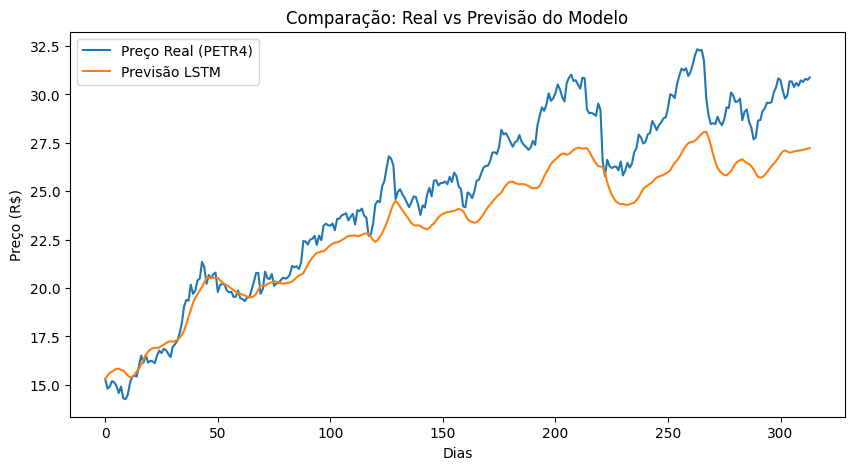

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

#Fazendo previsões com a base de validação
predictions = model.predict(x_val)

#Desfazendo a normalização para termos os valores reais em Reais R$
predictions_rescaled = scaler.inverse_transform(predictions)
y_val_rescaled = scaler.inverse_transform(y_val.reshape(-1, 1))

#calculando as metricas obrigatorias
mae = mean_absolute_error(y_val_rescaled, predictions_rescaled)
rmse = np.sqrt(mean_squared_error(y_val_rescaled, predictions_rescaled))
mape = np.mean(np.abs((y_val_rescaled - predictions_rescaled)/ y_val_rescaled))

print(f"MAE: {mae: .2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape: .2f}%")

plt.figure(figsize=(10, 5))
plt.plot(y_val_rescaled, label= 'Preço Real (PETR4)')
plt.plot(predictions_rescaled, label='Previsão LSTM')
plt.title('Comparação: Real vs Previsão do Modelo')
plt.xlabel('Dias')
plt.ylabel('Preço (R$)')
plt.legend()
plt.show()

#10 Salvamento do Modelo

Usamos a extensão .keras (padrão atual do TensorFlow) para exportar os pesos da rede e a arquitetura para o disco.

In [ ]:
#salvando o modelo treinado

model.save("modelo_lstm_petr4.keras")
print("Modelo exportado com sucesso!")

Modelo exportado com sucesso!
